In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, ks_2samp
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score


In [2]:
# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

# GPCRS - Gprot couplings

In [3]:
# Read GPCRs
gpcrs = pd.read_csv('/home/fraimondi/BIOINFO1_BK/francesco/GPCR/gpcrs_genes.txt')['Symbol'].values

# Read ligands
lr = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv')
gpcrs_lr = lr[lr.receptor.isin(gpcrs)]
gpcrs_ligands = list(set(gpcrs_lr.ligand))
lr_pairs = gpcrs_lr.set_index(['ligand', 'receptor']).index

# Read G-Proteins coupling
gprots_couplings = pd.read_csv('/home/lnemati/resources/gpcr_couplings/gpcr_couplings.csv')
gprots = list(set(gprots_couplings.gprot))

gprots_couplings = gprots_couplings.query('n_sources >= 3')
gprots_couplings = gprots_couplings.query('type != "precogx_only"')
gprots_couplings.set_index('gpcr', inplace=True, drop=False)
gprots_couplings.index.name = None
gprots_couplings = gprots_couplings.groupby('gpcr')['gprot'].apply(list)

gpcr_gprot_pairs = (
    gprots_couplings
    .explode()                # expand lists into rows
    .rename('gprot')
    .reset_index()            # gpcr becomes a column
    .set_index(['gpcr', 'gprot'])
    .index
)


In [4]:
# Get G-Proteins, GPCRs and their ligands
gpcrs_genes = list(set(gpcrs) | set(gprots) | set(lr.ligand.values) | set(lr.receptor.values))

# NEW Tumor Coevolution - GPCRS

In [5]:
path = '/projects/bioinformatics/DB/coevolution/CancerTracer/all_mutations'
#path = '/projects/bioinformatics/DB/coevolution/CancerTracer/only_non_synonym_amp_del'

coev_trunk = pd.read_csv(os.path.join(path, 'trunk', 'ratio.csv'), index_col=0)
coev_branch = pd.read_csv(os.path.join(path, 'branch', 'ratio.csv'), index_col=0)
coev_leaf = pd.read_csv(os.path.join(path, 'leaf', 'ratio.csv'), index_col=0)

In [109]:
def extract_pairs(coev, genes, pairs):
    # restrict to genes actually present
    valid = coev.index.intersection(genes)
    
    # subset safely
    tmp = coev.loc[valid, valid].stack()
    
    # filter desired pairs
    return tmp.loc[tmp.index.intersection(pairs)]

# Ligand - Receptor
coev_lr_trunk  = extract_pairs(coev_trunk,  gpcrs_genes, lr_pairs)
coev_lr_branch = extract_pairs(coev_branch, gpcrs_genes, lr_pairs)
coev_lr_leaf   = extract_pairs(coev_leaf,   gpcrs_genes, lr_pairs)

# GPCR - G Protein
coev_gprot_trunk  = extract_pairs(coev_trunk,  gpcrs_genes, gpcr_gprot_pairs)
coev_gprot_branch = extract_pairs(coev_branch, gpcrs_genes, gpcr_gprot_pairs)
coev_gprot_leaf   = extract_pairs(coev_leaf,   gpcrs_genes, gpcr_gprot_pairs)

In [110]:
# Combine coev data into a long-format DataFrame
all_data = []

# Add data from the 'Trunk' condition
for score in coev_lr_trunk:
    all_data.append({'value': score, 'interactor_type': 'Ligand', 'condition': 'Trunk'})
for score in coev_gprot_trunk:
    all_data.append({'value': score, 'interactor_type': 'G-Protein', 'condition': 'Trunk'})

# Add data from the 'Branch' condition
for score in coev_lr_branch:
    all_data.append({'value': score, 'interactor_type': 'Ligand', 'condition': 'Branch'})
for score in coev_gprot_branch:
    all_data.append({'value': score, 'interactor_type': 'G-Protein', 'condition': 'Branch'})

# Add data from the 'Private' condition
for score in coev_lr_leaf:
    all_data.append({'value': score, 'interactor_type': 'Ligand', 'condition': 'Private'})
for score in coev_gprot_leaf:
    all_data.append({'value': score, 'interactor_type': 'G-Protein', 'condition': 'Private'})

# Convert the combined data into a DataFrame
df_coev = pd.DataFrame(all_data)

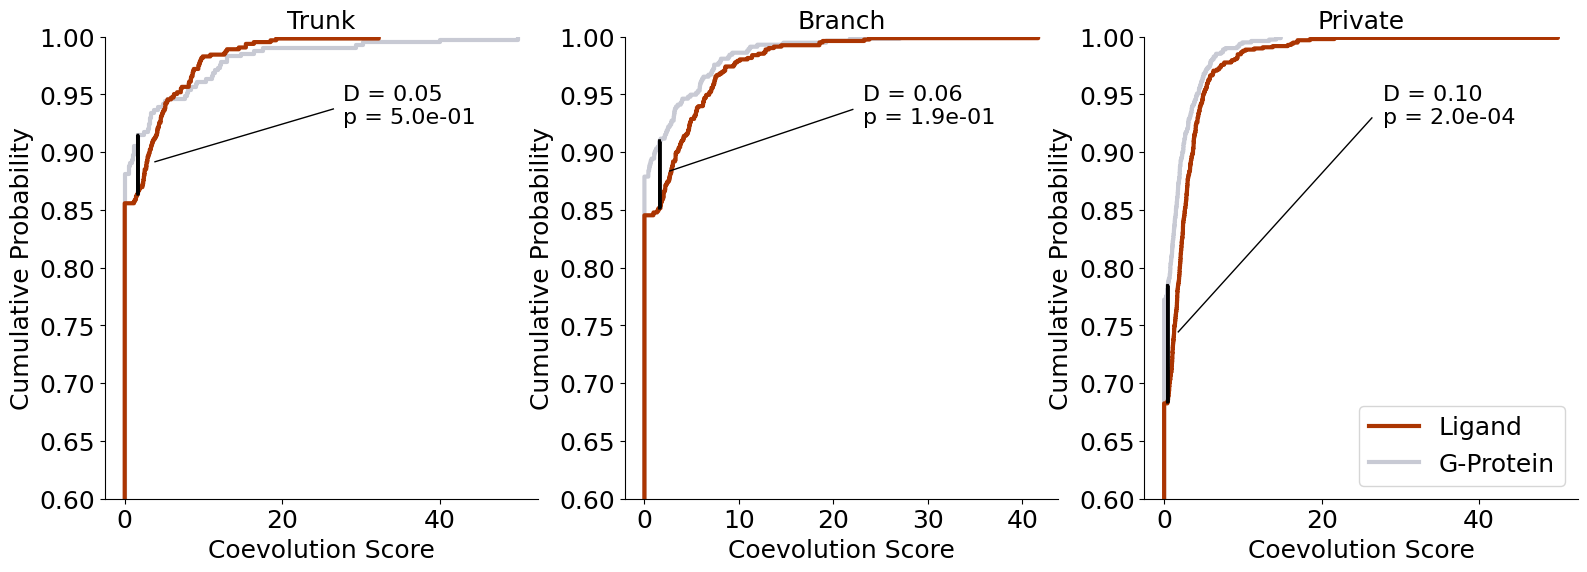

In [111]:
def plot_cdf_with_ks(data, condition, ax, color_ligand, color_gpcr):
    fs = 18

    # Set ylim and xlim based on condition
    ax.set_ylim(0.6, 1.)
    
    if condition == "Private":
        #ax.set_xlim(-0.01, 0.5)
        arrow_width = 0.01  # half width
        #ax.set_xticks([0, 0.25, 0.5])

    else:
        #ax.set_xlim(-0.01, 1)
        arrow_width = 0.02  # default width
        #ax.set_xticks([0, 0.25, 0.5, 0.75, 1.00])

    # Filter data for the given condition
    df_condition = data[data['condition'] == condition]
    ligand_values = df_condition[df_condition['interactor_type'] == 'Ligand']['value']
    gpcr_values = df_condition[df_condition['interactor_type'] == 'G-Protein']['value']
    
    # KS test
    ks_stat, p_value = ks_2samp(ligand_values, gpcr_values)
    
    # ECDF plots
    sns.ecdfplot(ligand_values, ax=ax, color=color_ligand, label='Ligand', linewidth=3, zorder=2)
    sns.ecdfplot(gpcr_values, ax=ax, color=color_gpcr, label='G-Protein', linewidth=3, zorder=1)

    # D-statistic logic
    cdf_ligand = np.sort(ligand_values)
    cdf_gpcr = np.sort(gpcr_values)
    all_values = np.sort(np.unique(np.concatenate((cdf_ligand, cdf_gpcr))))
    cdf_ligand_y = np.searchsorted(cdf_ligand, all_values, side='right') / len(cdf_ligand)
    cdf_gpcr_y = np.searchsorted(cdf_gpcr, all_values, side='right') / len(cdf_gpcr)
    max_diff_index = np.argmax(np.abs(cdf_ligand_y - cdf_gpcr_y))

    x_max_diff = all_values[max_diff_index]
    y1_max_diff = cdf_ligand_y[max_diff_index]
    y2_max_diff = cdf_gpcr_y[max_diff_index]
    midpoint_y = (y1_max_diff + y2_max_diff) / 2

    # Vertical D-statistic line and arrows
    ax.vlines(x_max_diff, y1_max_diff, y2_max_diff, color='k', linestyle='-', lw=2)
    ax.arrow(x_max_diff, y1_max_diff, 0, y2_max_diff - y1_max_diff, 
             color='k', linestyle='-', lw=2, head_width=arrow_width, head_length=0.02, length_includes_head=True, zorder=10)
    ax.arrow(x_max_diff, y2_max_diff, 0, y1_max_diff - y2_max_diff, 
             color='k', linestyle='-', lw=2, head_width=arrow_width, head_length=0.02, length_includes_head=True, zorder=10)

    # Annotation with KS stat
    text_object = ax.text(
        0.55, 0.85,
        f'D = {ks_stat:.2f}\np = {p_value:.1e}',
        fontsize=fs - 2, ha='left', va='center',
        transform=ax.transAxes,
    )

    text_x, text_y = text_object.get_position()
    max_diff_axis_rel = ax.transData.transform((x_max_diff, midpoint_y))
    max_diff_axis_rel_x, max_diff_axis_rel_y = ax.transAxes.inverted().transform(max_diff_axis_rel)

    direction_x = max_diff_axis_rel_x - text_x
    direction_y = max_diff_axis_rel_y - text_y

    offset_x = direction_x * 0.95
    offset_y = direction_y * 0.95

    start_x = text_x + offset_x
    start_y = text_y + offset_y
    end_x = max_diff_axis_rel_x - offset_x
    end_y = max_diff_axis_rel_y - offset_y

    ax.plot([start_x, end_x], [start_y, end_y], color='k', lw=1, linestyle='-', zorder=9, transform=ax.transAxes)

    # Axis labels and legend
    ax.set_title(f'{condition}', fontsize=fs)
    ax.set_xlabel('Coevolution Score', fontsize=fs)
    ax.set_ylabel('Cumulative Probability', fontsize=fs)
    ax.tick_params(labelsize=fs)
    ax.legend(fontsize=fs, loc='lower right')
    ax.grid(False)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Create a subplot mosaic with 1x3 grid layout
fig = plt.figure(figsize=(19, 6))

# Create the axes using the subplot mosaic
axes = fig.subplot_mosaic(
    """
    ABC
    """
)

# Plot for each condition
for i, condition in enumerate(df_coev['condition'].unique()):
    plot_cdf_with_ks(df_coev, condition, axes[chr(65 + i)], tcolor, lightgray)

# Remove legends from the first two axes
for ax in axes['A'], axes['B']:
    ax.legend_.remove()

# Save the figure
#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/gpcrs_tumor_coevolution.png', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/gpcrs_tumor_coevolution.pdf', bbox_inches='tight', dpi=300)

# Show the plot
#plt.show()

#### 

# ROC Curve

In [6]:
from itertools import product

# Function that generates and saves the ROC curve
def generate_roc_curve(
    data,
    target_col,
    feature_col,
):
    # ROC curve using all gene pairs
    fpr, tpr, thr = roc_curve(data[target_col], data[feature_col])
    auroc = roc_auc_score(data[target_col], data[feature_col])
    
    return fpr, tpr, thr, auroc

def update_diff_complex(
    all_pairs,
    genes_series_a,
    genes_series_b
):
    for genes_a, genes_b in zip(genes_series_a, genes_series_b):
        for pair in product(genes_a, genes_b):
            gene_a, gene_b = pair
            if pair in all_pairs.index:
                all_pairs.loc[pair, "interaction"] = 1
            elif (gene_b, gene_a) in all_pairs.index:
                all_pairs.loc[(gene_b, gene_a), "interaction"] = 1
    return

print("Reading interactions.csv")
# read interactions.csv 
interactions = pd.read_csv('/projects/bioinformatics/DB/CellCellCommunication/WithEnzymes/cpdb_cellchat_enz.csv')
#coev = pd.read_csv('/home/lnemati/resources/coevolution/jaccard_genes.csv.gz', index_col=0)

# Extract genes for complex A and B for each row
complex_a_genes = interactions.apply(lambda row: list(set([row[f'interactor{i}'] for i in range(1, row['num_interactors_a'] + 1) if pd.notna(row[f'interactor{i}'])])), axis=1)
complex_b_genes = interactions.apply(lambda row: list(set([row[f'interactor{i}'] for i in range(row['num_interactors_a'] + 1, row['num_interactors_a'] + row['num_interactors_b'] + 1) if pd.notna(row[f'interactor{i}'])])), axis=1)
interactions_all_genes = complex_a_genes + complex_b_genes

# make all_interacting_genes a list containing all unique genes in the interactions
all_interacting_genes = list(set().union(*interactions_all_genes))
print("Number of interacting genes: ", len(all_interacting_genes))


Reading interactions.csv
Number of interacting genes:  1576


In [7]:
coev = coev_leaf

In [8]:
# ----- ROC all gene pairs -----

print("Generating ROC curves")

print("coev has shape: ", coev.shape)

# flatten TOM matrix, remove diagonal and duplicated values
print("Flattening coev matrix")
all_pairs = pd.DataFrame(
    coev.where(
        np.tri(
            coev.shape[0],
            dtype=bool,
            k=-1
        ),
        np.nan
    ).stack(dropna=True), columns=["coev"]
)
print("all_pairs has now shape: ", all_pairs.shape)

all_pairs['interaction'] = 0

update_diff_complex(all_pairs, complex_a_genes, complex_b_genes)

print("Total number of interacting pairs: ", all_pairs["interaction"].sum())

Generating ROC curves
coev has shape:  (20142, 20142)
Flattening coev matrix


/var/tmp/pbs.435159.pbs01/ipykernel_63813/1490307984.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  coev.where(


all_pairs has now shape:  (202839669, 1)
Total number of interacting pairs:  3433


In [9]:
# Get max finite value (ignore inf and NaN)
max_finite = all_pairs.coev[np.isfinite(all_pairs.coev)].max()

# Replace +inf and -inf
all_pairs.coev = all_pairs.coev.replace([np.inf, -np.inf], max_finite)

In [10]:
# Diff complex interactions
coev_fpr, coev_tpr, coev_ths, coev_auroc = generate_roc_curve(
    data=all_pairs,
    target_col="interaction",
    feature_col="coev",
    #name='Coevoulution'
) 

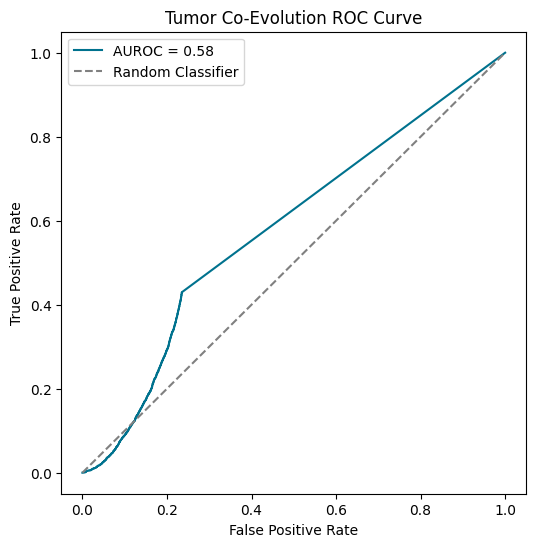

In [11]:
plt.figure(figsize=(6, 6))
plt.plot(coev_fpr, coev_tpr, label=f'AUROC = {coev_auroc:.2f}', color=ncolor)
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tumor Co-Evolution ROC Curve')
plt.legend(loc='upper left')
#plt.grid(True)
plt.show()

In [ ]:
coev_fpr, coev_tpr, coev_ths

In [19]:
all_pairs.coev.sort_values()

TTN        TP53           -2.017342
SLC10A1    HSD11B2         0.000000
           HS3ST5          0.000000
           HS3ST6          0.000000
           HS6ST1          0.000000
                            ...    
EIF2B2     BAGE3         999.999940
LINC01192  CCZ1B         999.999940
OVOS2      ANKRD65       999.999940
MIR4445    ENPP7P13      999.999940
TMEM174    SRGAP2-AS1    999.999940
Name: coev, Length: 202839669, dtype: float64

In [23]:
all_pairs[all_pairs['interaction'] == 1].sort_values(by='coev')

coev  interaction
SLC18A2 DRD2    0.000000            1
LAMB3   DAG1    0.000000            1
LAMB2   CD44    0.000000            1
SLC18A1 ADRB3   0.000000            1
        DRD2    0.000000            1
...                  ...          ...
HRH4    AOC1   18.518518            1
LIF     IL6ST  20.408163            1
NAPEPLD CNR2   21.621622            1
MICA    KLRK1  27.027027            1
RXFP4   INSL3  50.000000            1

[3433 rows x 2 columns]

In [ ]:
all_pairs[all_pairs['interaction'] == 0].sort_values(by='coev')

# Get incidence matrices

In [4]:
date_to_gene = {
    '1-Dec':  'DEC1',   # DELEC1? or could be DECR1 — need context
    '1-Mar':  'MARCH1',
    '1-Sep':  'SEPT1',
    '10-Mar': 'MARCH10',
    '15-Sep': 'SEPT15',
    '2-Mar':  'MARCH2',
    '3-Mar':  'MARCH3',
    '3-Sep':  'SEPT3',
    '4-Mar':  'MARCH4',
    '4-Sep':  'SEPT4',
    '6-Mar':  'MARCH6',
    '6-Sep':  'SEPT6',
    '7-Mar':  'MARCH7',
    '8-Mar':  'MARCH8',
    '9-Sep':  'SEPT9',
}

In [5]:
df_complete = pd.read_csv('/projects/bioinformatics/DB/CancerTracer/intra_heterogeneity_data.txt', sep='\t')

# Remove wrongly formatted row
df_complete = df_complete[~df_complete.index.isin(['p075_p3'])]

In [138]:
import re
import pandas as pd

def extract_mutation_info(mutation_string, allowed_strings=None):
    # Return empty lists if the input string is missing or empty
    if pd.isna(mutation_string) or mutation_string == '':
        return [], [], []

    # Split the string into individual entries
    gene_entries = mutation_string.split(',')
    
    if allowed_strings is None:
        filtered_entries = [entry for entry in gene_entries]
    else:
    # Filter entries that have allowed patterns and contain a closing parenthesis
        filtered_entries = [entry for entry in gene_entries if any([x in entry for x in allowed_strings]) and ')' in entry]

    # Initialize lists to store genes, mutations, and samples
    genes = []
    mutations = []
    samples = []

    # Process each filtered entry
    for entry in filtered_entries:
        # Get gene: Keep only the text before the first set of parentheses
        gene = re.sub(r'\s*\(.*$', '', entry).strip()

        # Get mutation: Extract the content inside the parentheses
        mutation_match = re.search(r'\(([^()]*)\)', entry)
        mutation = mutation_match.group(1).strip() if mutation_match else ''

        # Get sample: Keep only the text after the first set of parentheses
        sample_match = re.search(r'\(.*?\)\s*([- ]*)(.*)', entry)
        sample = sample_match.group(2).strip('- ').strip() if sample_match else ''

        # Append the parsed components to respective lists
        genes.append(gene)
        mutations.append(mutation)
        samples.append(sample)

    # Return the lists of genes, mutations, and samples
    return genes, mutations, samples


In [144]:
# ALL MUTATIONS

dfs = []

for col in ['Trunk_mutation', 'Branch_mutation', 'Private_mutation']:
    # Separate individual mutations
    # Use regex to split only on commas that are not inside parentheses
    vals = df_complete[col].str.split(r',\s*(?![^(]*\))', expand=True)
    
    # Find nans
    keep = ~vals.isna()
    
    # Add sample ids
    samples = df_complete['Sample']
    samples.index = samples.values
    vals.index = samples.values
    vals = (vals.T.astype(str) + samples).T
    
    # Remove nans
    vals = vals.values[keep]

    # CHANGE THIS TO GO FROM ALL MUTATIONS TO ONLY P, AMP, DEL
    
    #allowed_strings = ['(p.', '(amp', '(del']
    allowed_strings = None
    
    genes, mutations, samples = extract_mutation_info(", ".join(vals), allowed_strings = allowed_strings)
    
    #genes     = [get_gene(x)     for x in vals]
    #mutations = [get_mutation(x) for x in vals]
    #samples   = [get_sample(x)   for x in vals]
    
    mutations_df = pd.DataFrame()
    mutations_df.index = genes
    mutations_df['mutation'] = mutations
    mutations_df['patient'] = samples
    mutations_df['when'] = col.strip('_mutation')
    
    dfs.append(mutations_df)
    
mutations_df = pd.concat(dfs)
mutations_df['gene'] = mutations_df.index

mutations_df = mutations_df[~mutations_df.index.isin(['', ' ', '-'])]
mutations_df = mutations_df[~mutations_df['patient'].isin(['', ' ', '-'])]
mutations_df = mutations_df[~mutations_df['gene'].isin(['', ' ', '-'])]

# Some genes were interpreted as dates by excel, fix that
mutations_df['gene'] = mutations_df['gene'].replace(date_to_gene)
mutations_df['when'] = mutations_df['when'].replace({'Private': 'Leaf'})

# Get incidence matrices
trunk  = mutations_df.query('when == "Trunk"')
branch = mutations_df.query('when in ["Trunk", "Branch"]')
leaf   = mutations_df  # all

def make_incidence(df):
    return (
        df.assign(value=1)
        .pivot_table(index="gene", columns="patient", values="value", fill_value=0, aggfunc="max")
    ).astype(int)

incidence_matrices = {
    'trunk':  make_incidence(trunk),
    'branch': make_incidence(branch),
    'leaf':   make_incidence(leaf),
}

# Save
parent_dir = '/projects/bioinformatics/DB/coevolution/CancerTracer/all_mutations'

for k, df in incidence_matrices.items():
    df.to_csv(os.path.join(parent_dir, k, 'incidence.csv'))

In [155]:
# ONLY P AMP DEL MUTATIONS

dfs = []

for col in ['Trunk_mutation', 'Branch_mutation', 'Private_mutation']:
    # Separate individual mutations
    # Use regex to split only on commas that are not inside parentheses
    vals = df_complete[col].str.split(r',\s*(?![^(]*\))', expand=True)
    
    # Find nans
    keep = ~vals.isna()
    
    # Add sample ids
    samples = df_complete['Sample']
    samples.index = samples.values
    vals.index = samples.values
    vals = (vals.T.astype(str) + samples).T
    
    # Remove nans
    vals = vals.values[keep]

    # CHANGE THIS TO GO FROM ALL MUTATIONS TO ONLY P, AMP, DEL
    
    allowed_strings = ['(p.', '(amp', '(del']
    #allowed_strings = None
    
    genes, mutations, samples = extract_mutation_info(", ".join(vals), allowed_strings = allowed_strings)
    
    #genes     = [get_gene(x)     for x in vals]
    #mutations = [get_mutation(x) for x in vals]
    #samples   = [get_sample(x)   for x in vals]
    
    mutations_df = pd.DataFrame()
    mutations_df.index = genes
    mutations_df['mutation'] = mutations
    mutations_df['patient'] = samples
    mutations_df['when'] = col.strip('_mutation')
    
    dfs.append(mutations_df)
    
mutations_df = pd.concat(dfs)
mutations_df['gene'] = mutations_df.index

mutations_df = mutations_df[~mutations_df.index.isin(['', ' ', '-'])]
mutations_df = mutations_df[~mutations_df['patient'].isin(['', ' ', '-'])]
mutations_df = mutations_df[~mutations_df['gene'].isin(['', ' ', '-'])]

# Some genes were interpreted as dates by excel, fix that
mutations_df['gene'] = mutations_df['gene'].replace(date_to_gene)
mutations_df['when'] = mutations_df['when'].replace({'Private': 'Leaf'})

# Get incidence matrices
trunk  = mutations_df.query('when == "Trunk"')
branch = mutations_df.query('when in ["Trunk", "Branch"]')
leaf   = mutations_df  # all

def make_incidence(df):
    return (
        df.assign(value=1)
        .pivot_table(index="gene", columns="patient", values="value", fill_value=0, aggfunc="max")
    ).astype(int)

incidence_matrices = {
    'trunk':  make_incidence(trunk),
    'branch': make_incidence(branch),
    'leaf':   make_incidence(leaf),
}

# Save
parent_dir = '/projects/bioinformatics/DB/coevolution/CancerTracer/only_non_synonym_amp_del'

for k, df in incidence_matrices.items():
    df.to_csv(os.path.join(parent_dir, k, 'incidence.csv'))